In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import math
import cartopy.crs as ccrs
import cartopy.feature as cfeature

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.visualization_helper import plot_scree, plot_eof_maps, plot_pc_timeseries

### Data import


In [ ]:
features_target = pd.read_csv("../data/processed/features_target.csv")

In [57]:
features_target

,id,msl_PC1,msl_PC2,msl_PC3,msl_PC4,msl_PC5,msl_PC6,msl_PC7,msl_PC8,msl_PC9,...,q_PC1393,q_PC1394,q_PC1395,q_PC1396,q_PC1397,q_PC1398,q_PC1399,q_PC1400,q_PC1401,target
0,0,-1.086083,-0.077619,0.720649,0.841423,1.963665,1.876230,1.845664,-0.249472,1.525257,...,1.177152,2.073178,0.873610,-2.161814,-0.013655,0.241100,0.189126,1.050111,0.742577,0
1,1,0.351382,-1.410374,0.916229,0.230294,0.875902,1.129672,0.740385,-0.084729,-0.555099,...,-0.317950,0.108386,-0.543964,0.868027,-0.338644,0.717657,-1.612489,-0.520248,-1.761038,0
2,2,-1.577106,0.511114,-0.353667,-0.578866,0.308943,-0.686001,-0.403937,0.866504,-0.954608,...,-0.188143,0.090743,2.718525,0.868271,-1.810065,1.294824,0.640850,2.655962,1.185709,0
3,3,-0.395485,-0.651588,0.413289,-0.137376,0.135449,3.351272,-0.495732,-0.448166,0.990854,...,-1.716604,-0.128737,-0.475332,-2.137106,-1.301202,-1.311810,-0.658927,-1.228352,1.390679,0
4,4,-1.092064,0.015592,-1.428686,1.424694,-1.461902,0.692937,-1.782076,-2.169061,0.488504,...,0.576226,0.216858,0.422626,-1.783211,0.800609,0.668926,0.381159,0.780959,-0.308130,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159570,159570,0.771463,0.663859,-0.986654,-3.233252,0.662774,1.719541,-1.258140,-0.075928,-1.780475,...,1.685132,-1.823222,-1.649464,-0.567231,-1.657178,0.120068,-0.648108,-0.442124,-0.319029,0
159571,159571,-1.188816,-1.218833,0.476259,0.451916,-0.769178,-0.993485,1.951063,0.039696,-0.895129,...,0.867280,1.055398,-1.937302,0.043057,-0.017958,-0.195368,-1.238956,1.272556,0.004786,0
159572,159572,-0.784478,0.760354,-3.051200,0.134340,1.005487,0.709072,0.461877,-1.219624,0.803701,...,-1.056096,-0.652371,-0.114110,3.031874,-1.769091,-0.157162,-0.417268,0.096955,0.000571,0
159573,159573,-1.037551,-0.263898,-1.826159,0.304277,1.237469,0.097588,-0.134887,-0.086346,-0.387491,...,-1.309938,-0.835096,-0.670816,-1.029428,-1.440228,1.403807,-1.369677,1.490964,0.172132,0


In [22]:
msl_explained_variance = pd.read_csv("../data/processed/pca_results/msl_explained_variance.csv", index_col=0)
msl_explained_variance = msl_explained_variance['Explained Variance Ratio']
msl_eofs = xr.open_dataset("../data/processed/pca_results/msl_eofs.nc")
msl_eofs = msl_eofs['eof_msl']

z500_explained_variance = pd.read_csv("../data/processed/pca_results/z500_explained_variance.csv", index_col=0)
z500_explained_variance = z500_explained_variance['Explained Variance Ratio']
z500_eofs = xr.open_dataset("../data/processed/pca_results/z500_eofs.nc")
z500_eofs = z500_eofs['eof_z']

q850_explained_variance = pd.read_csv("../data/processed/pca_results/q850_explained_variance.csv", index_col=0)
q850_explained_variance = q850_explained_variance['Explained Variance Ratio']
q850_eofs = xr.open_dataset("../data/processed/pca_results/q850_eofs.nc")
q850_eofs = q850_eofs['eof_q']

### Mean Sea Level Pressure (MSLP)

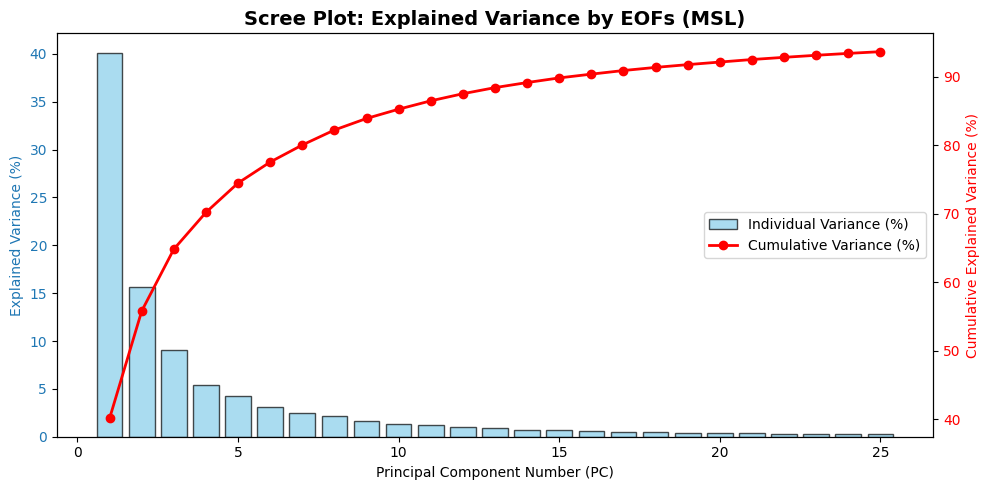

In [26]:
plot_scree(msl_explained_variance, var_name='msl', max_eofs=25)

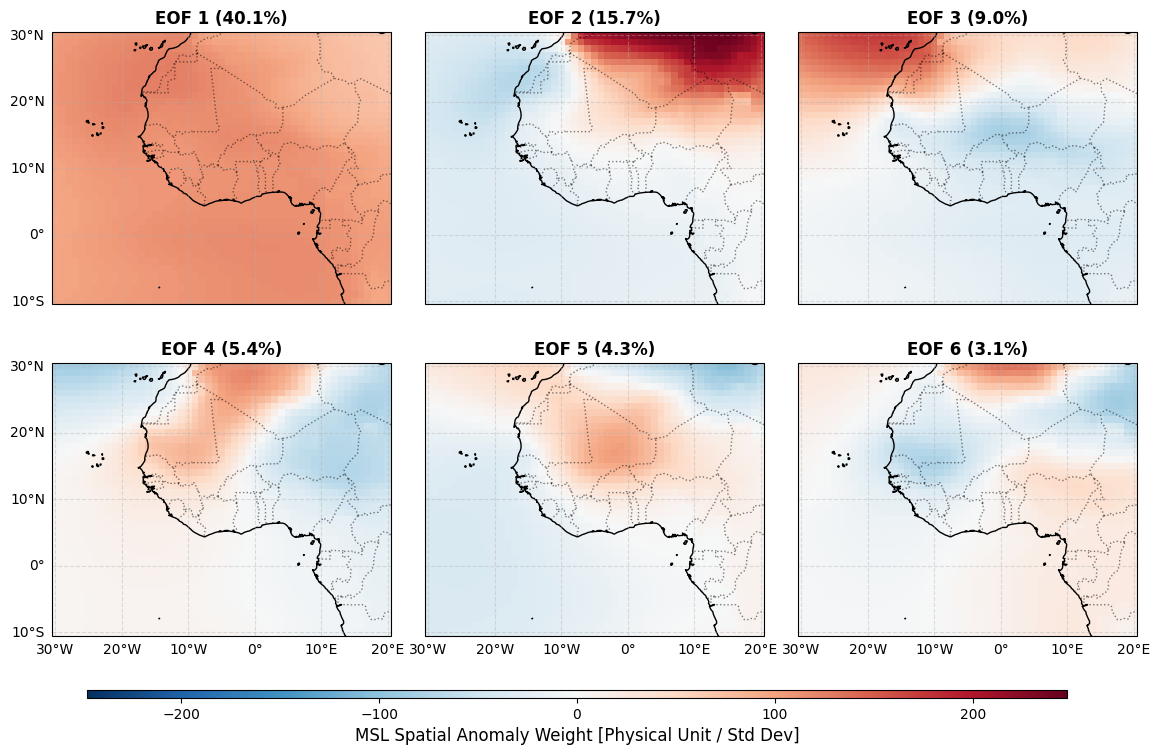

In [24]:
plot_eof_maps(eofs_da=msl_eofs,
              explained_variance=msl_explained_variance, 
              var_name='msl',
              max_eofs=6)

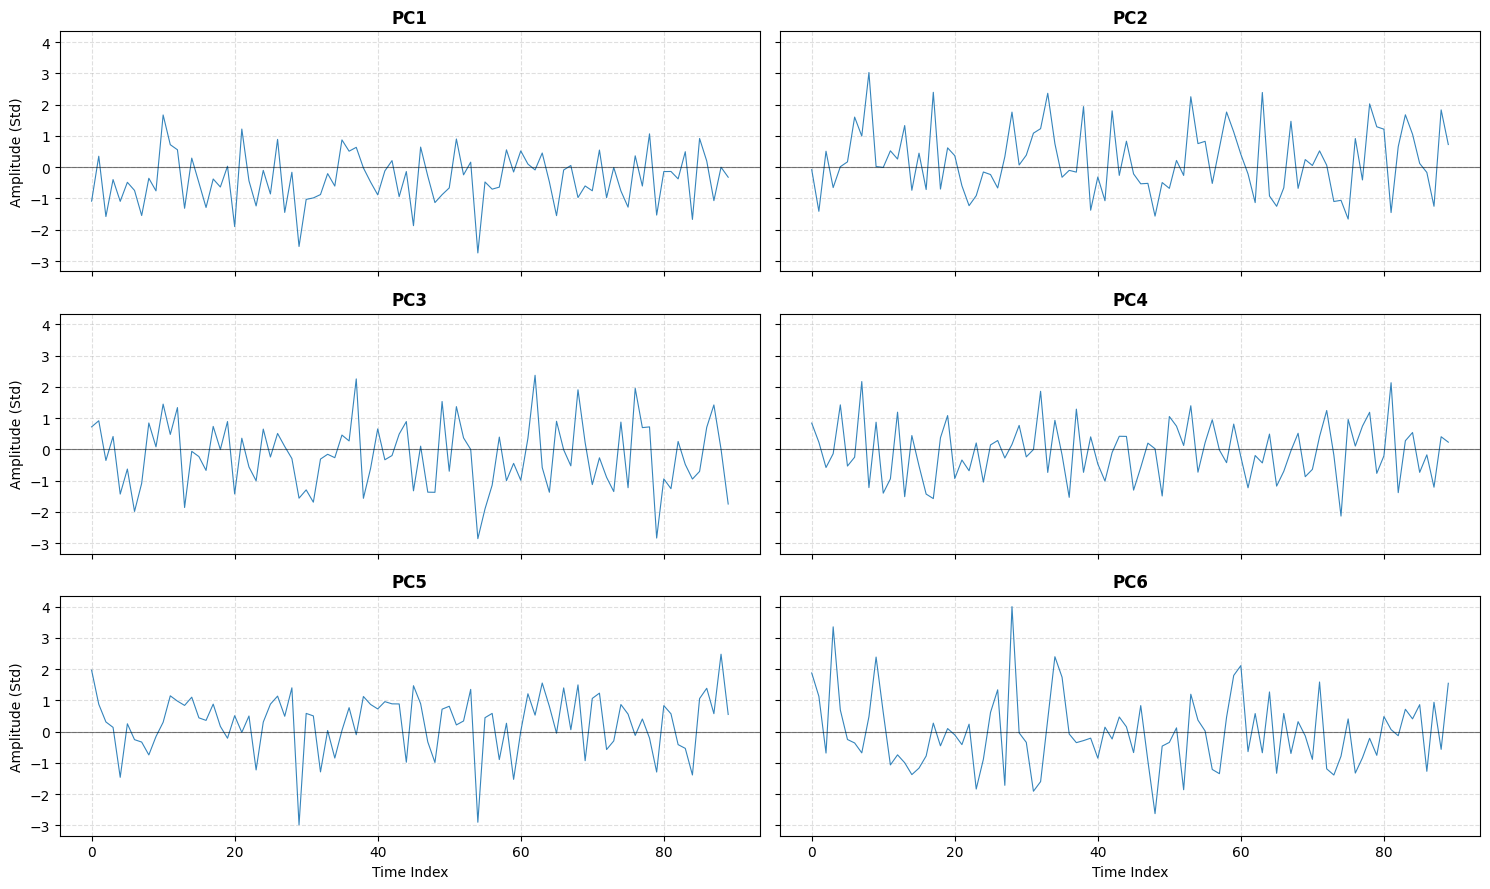

In [17]:
plot_pc_timeseries(features_target.iloc[:90], var_name='msl', max_eofs=6)

### Geopotential Height at 500 hPa


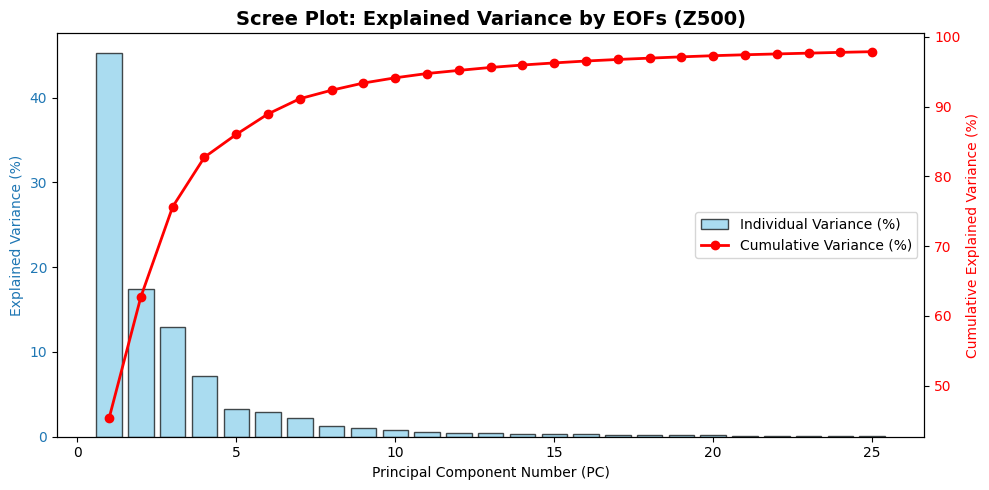

In [27]:
plot_scree(z500_explained_variance, var_name='z500', max_eofs=25)

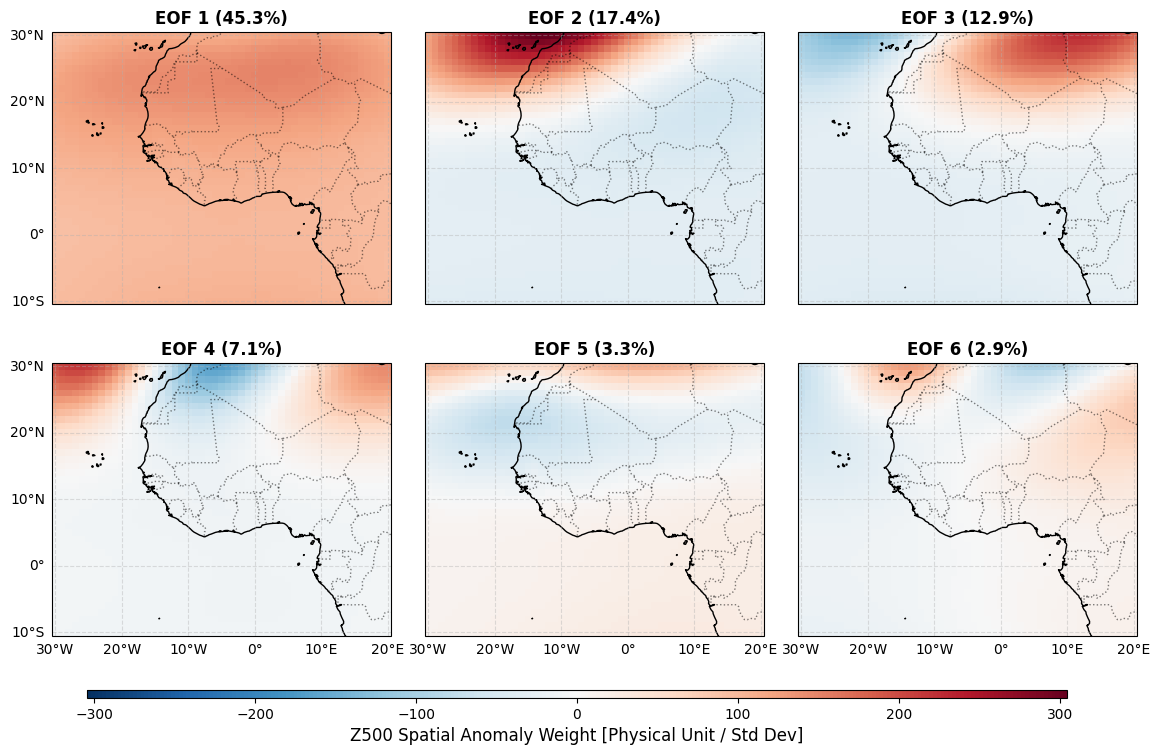

In [28]:
plot_eof_maps(eofs_da=z500_eofs,
              explained_variance=z500_explained_variance, 
              var_name='z500',
              max_eofs=6)

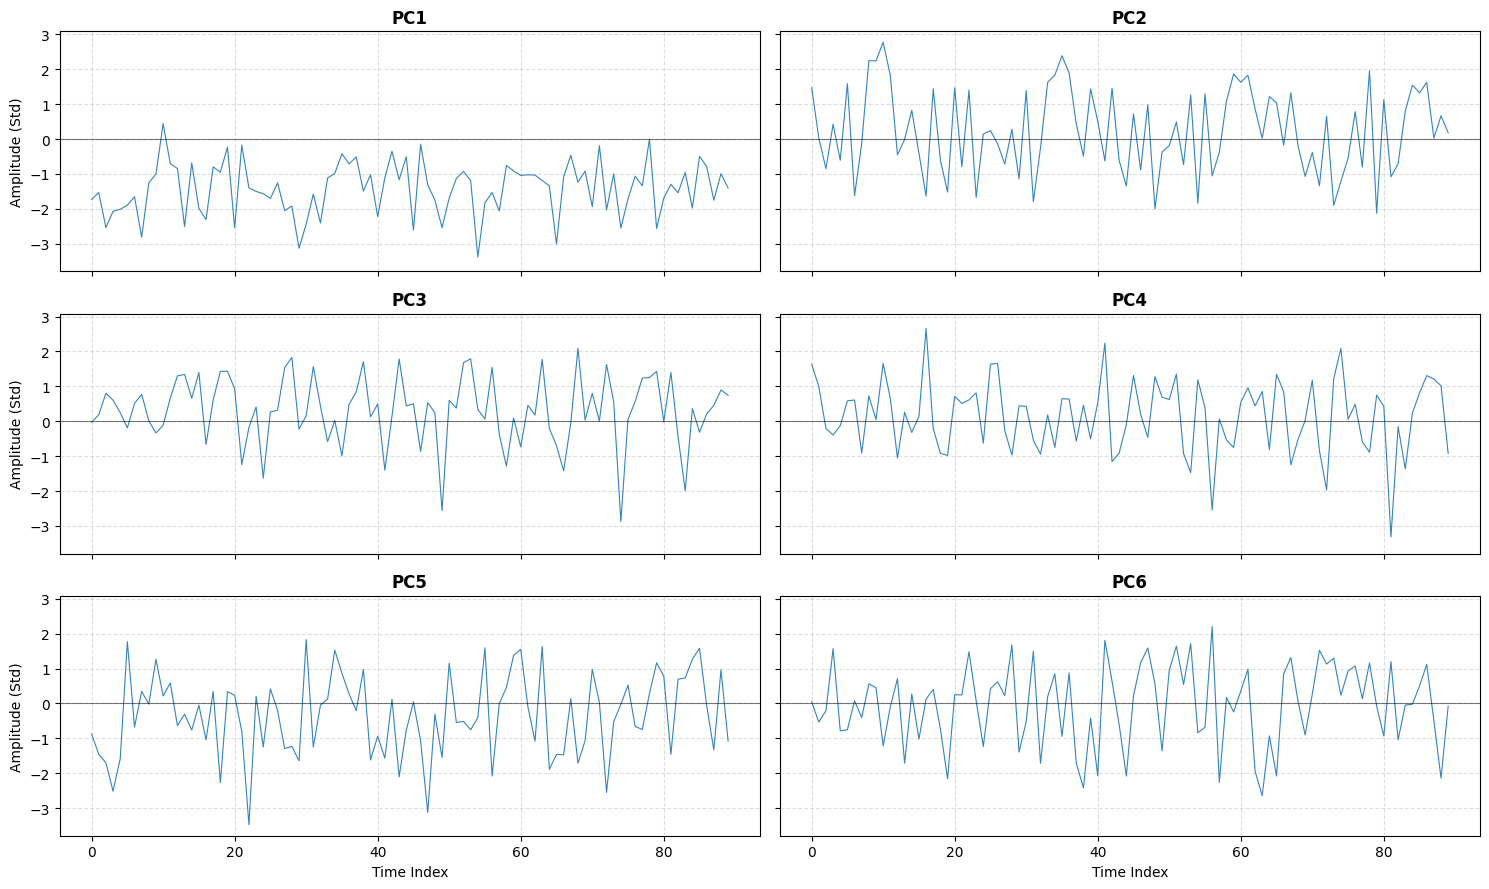

In [30]:
plot_pc_timeseries(features_target.iloc[:90], var_name='z', max_eofs=6)

### Specific Humidity at 850 hPa

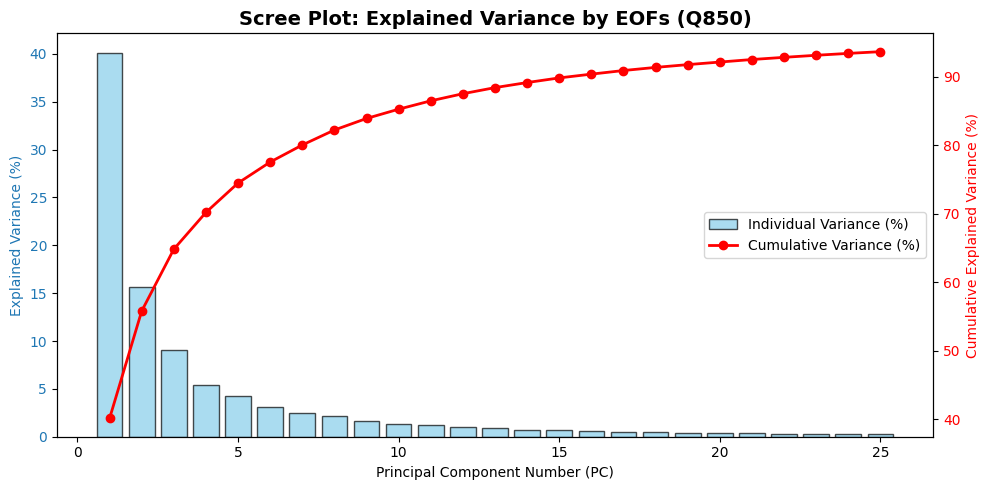

In [31]:
plot_scree(msl_explained_variance, var_name='q850', max_eofs=25)

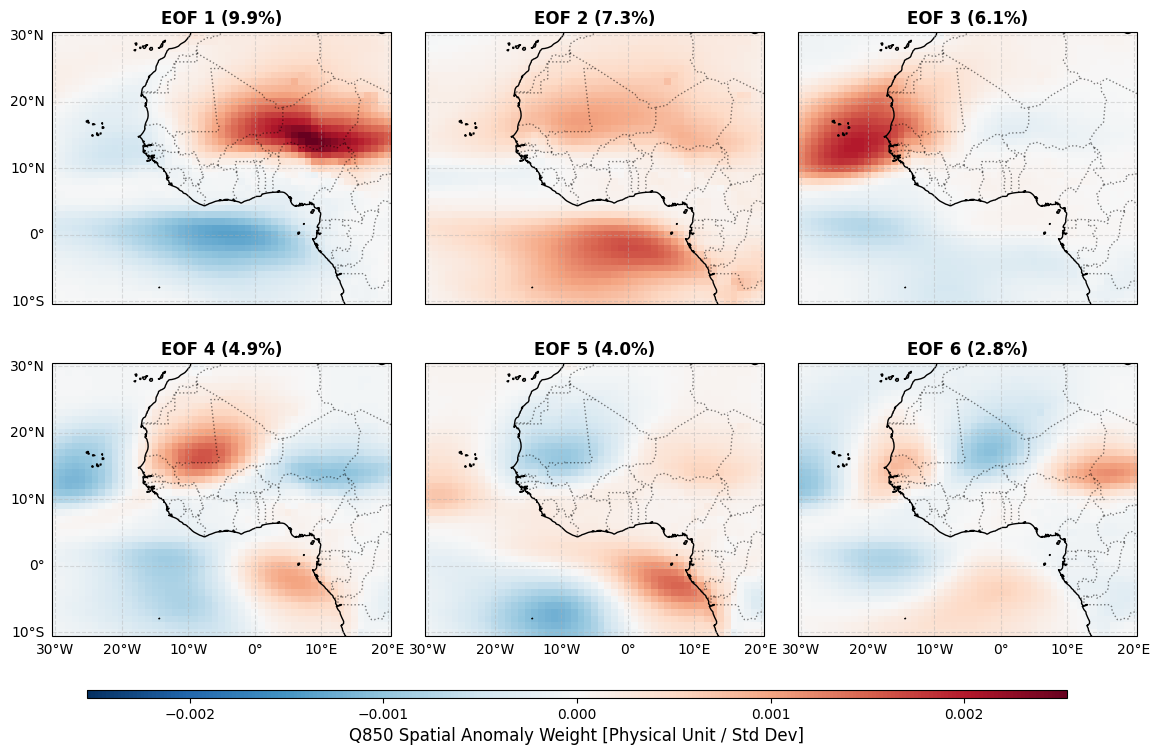

In [32]:
plot_eof_maps(eofs_da=q850_eofs,
              explained_variance=q850_explained_variance, 
              var_name='q850',
              max_eofs=6)

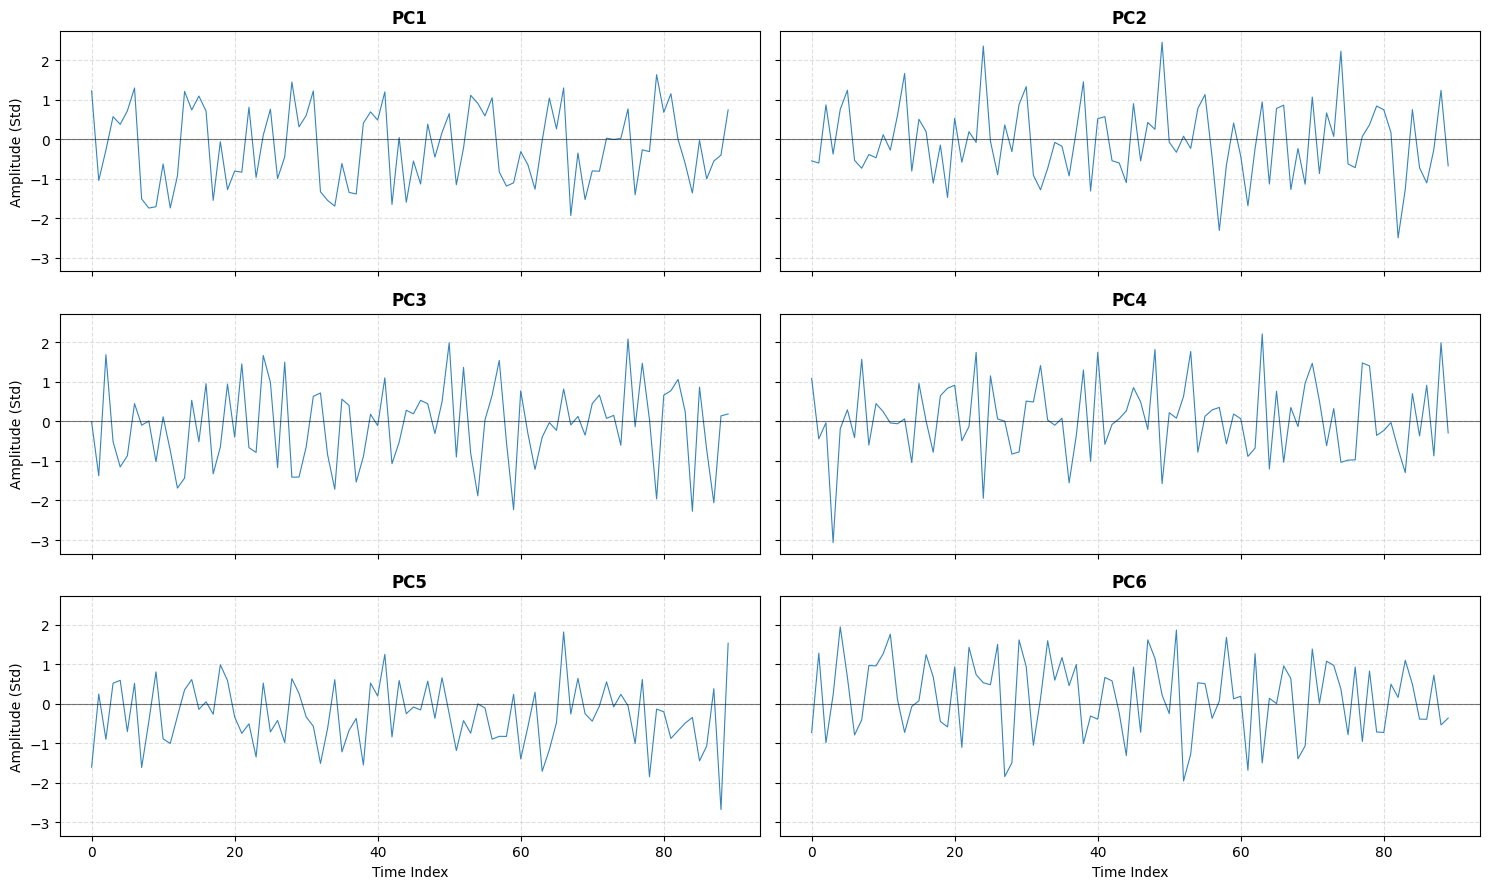

In [33]:
plot_pc_timeseries(features_target.iloc[:90], var_name='q', max_eofs=6)

### Comparison

In [55]:
def plot_variance_comparison(variance_dict: dict, max_eofs: int = 10, cumulative_threshold: float = 0.8):
    """
    Plot a scree plot comparing individual and cumulative explained variance 
    for multiple variables.

    Parameters
    ----------
    variance_dict : dict
        A dictionary where keys are strings (variable names) and values are 
        pandas Series containing the explained variance ratios.
    max_eofs : int, optional
        The maximum number of EOF modes to display on the x-axis. Default is 10.
    cumulative_threshold : float, optional
        A reference line for the cumulative variance plot (e.g., 0.8 for 80%). 
        Default is 0.8.
        
    Returns
    -------
    None
        Renders and displays the matplotlib figure.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define a color palette for the variables
    colors = plt.cm.tab10.colors 
    
    for idx, (var_name, var_series) in enumerate(variance_dict.items()):
        color = colors[idx % len(colors)]
        
        # Ensure we only plot up to max_eofs or the length of the series
        n_points = min(max_eofs, len(var_series))
        
        # Data slicing
        # Assuming the index is 0-based in the CSV, we shift by 1 for EOF labels (1, 2, 3...)
        x_vals = np.arange(1, n_points + 1)
        y_individual = var_series.iloc[:n_points].values *100  # Convert to percentage
        y_cumulative = var_series.cumsum().iloc[:n_points].values *100  # Convert to percentage
        
        # Panel 1: Individual Explained Variance (Scree Plot)
        ax1.plot(x_vals, y_individual, marker='o', linestyle='-', linewidth=2, 
                 color=color, label=var_name.upper(), alpha=0.8)
        
        # Panel 2: Cumulative Explained Variance
        ax2.plot(x_vals, y_cumulative, marker='s', linestyle='--', linewidth=2, 
                 color=color, label=var_name.upper(), alpha=0.8)

    # --- Formatting Panel 1 (Individual) ---
    ax1.set_title('Individual Explained Variance (Scree Plot)', fontweight='bold')
    ax1.set_xlabel('EOF Mode')
    ax1.set_ylabel('Explained Variance Ratio (%)')
    ax1.set_yticks(np.arange(0, 60, 10), )
    ax1.set_xticks(np.arange(1, max_eofs + 1))
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Formatting Panel 2 (Cumulative) ---
    ax2.set_title('Cumulative Explained Variance', fontweight='bold')
    ax2.set_xlabel('EOF Mode')
    ax2.set_ylabel('Cumulative Variance Ratio (%)')
    ax2.set_yticks(np.arange(0, 101, 10))
    ax2.set_xticks(np.arange(1, max_eofs + 1))

    
    # # Add a reference threshold line (e.g., 80% variance explained)
    # ax2.axhline(cumulative_threshold, color='black', linestyle='-.', 
    #             linewidth=1.2, label=f'{cumulative_threshold*100:.0f}% Threshold')
    
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

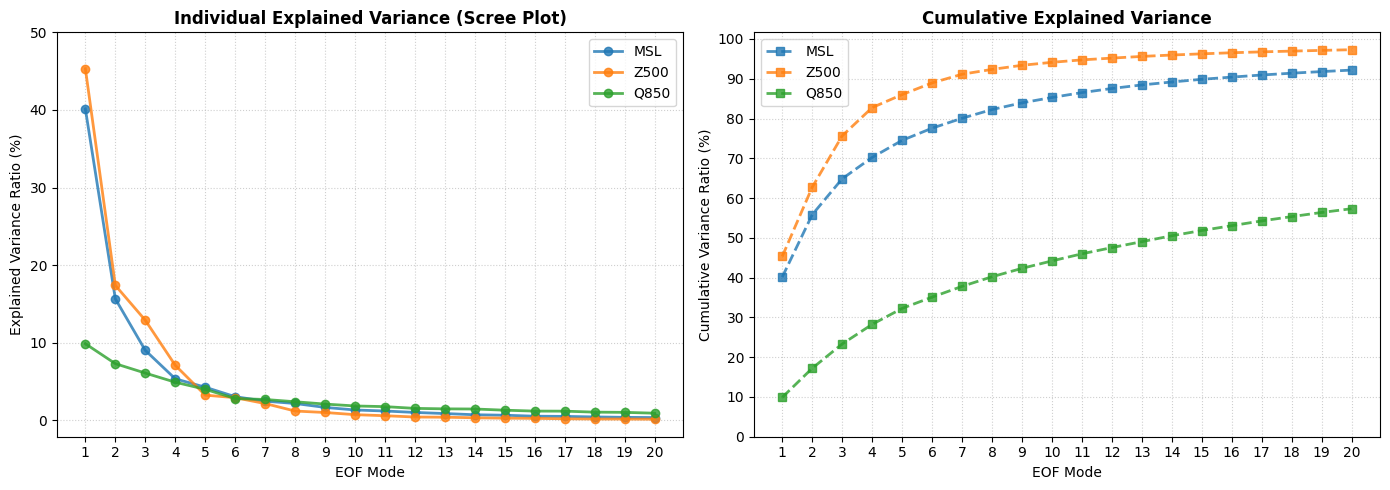

In [56]:
variance_data = {
    'MSL': msl_explained_variance,
    'Z500': z500_explained_variance,
    'Q850': q850_explained_variance
}
plot_variance_comparison(variance_dict=variance_data, max_eofs=20, cumulative_threshold=0.9)

In [52]:
def plot_cumulative_variance_comparison(variance_dict: dict, max_eofs: int = 10):
    """
    Plot a scree plot comparing individual and cumulative explained variance 
    for multiple variables.

    Parameters
    ----------
    variance_dict : dict
        A dictionary where keys are strings (variable names) and values are 
        pandas Series containing the explained variance ratios.
    max_eofs : int, optional
        The maximum number of EOF modes to display on the x-axis. Default is 10.
        
    Returns
    -------
    None
        Renders and displays the matplotlib figure.
    """
    fig,  ax2 = plt.subplots(1, 1, figsize=(7, 5))
    
    # Define a color palette for the variables
    colors = plt.cm.tab10.colors 
    
    for idx, (var_name, var_series) in enumerate(variance_dict.items()):
        color = colors[idx % len(colors)]
        
        # Ensure we only plot up to max_eofs or the length of the series
        n_points = min(max_eofs, len(var_series))
        
        # Data slicing
        # Assuming the index is 0-based in the CSV, we shift by 1 for EOF labels (1, 2, 3...)
        x_vals = np.arange(1, n_points + 1)
        y_cumulative = var_series.cumsum().iloc[:n_points].values *100  # Convert to percentage
        
        
        # Panel 2: Cumulative Explained Variance
        ax2.plot(x_vals, y_cumulative, marker='s', linestyle='--', linewidth=2, 
                 color=color, label=var_name.upper(), alpha=0.8)


    # --- Formatting Panel 2 (Cumulative) ---
    ax2.set_title('Cumulative Explained Variance', fontweight='bold')
    ax2.set_xlabel('EOF Mode')
    ax2.set_ylabel('Cumulative Variance Ratio (%)')
    ax2.set_yticks(np.arange(0, 101, 10))
    ax2.set_xticks(np.arange(1, max_eofs + 1))

    
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

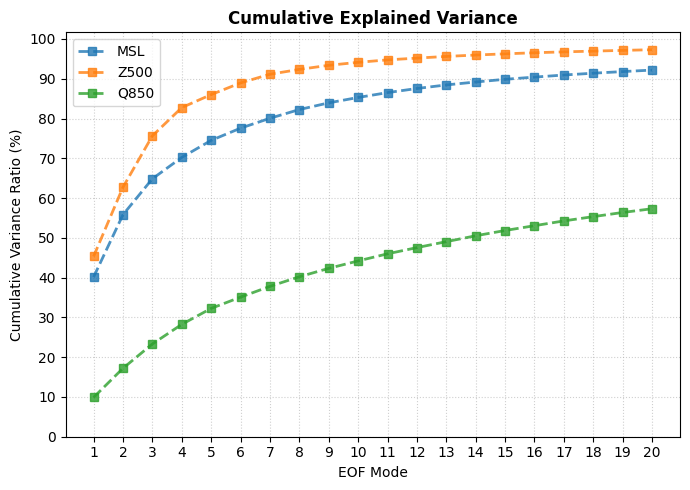

In [54]:
variance_data = {
    'MSL': msl_explained_variance,
    'Z500': z500_explained_variance,
    'Q850': q850_explained_variance
}
plot_cumulative_variance_comparison(variance_dict=variance_data, max_eofs=20)